In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from dotenv import find_dotenv, load_dotenv
import time
from PIL import Image




In [ ]:
#load in the train data - explore and clean

#find the environment file
env_file = find_dotenv()
load_dotenv()

#path to train images
path = os.getenv("DR_IMAGES_PATH")
#path to csv file containing img id code and grading
label_csv = os.getenv("DR_LABELS_PATH")


if not os.path.isfile(label_csv):
    print(f"File not found")
else:
    pass


try:
    with open (label_csv, "r") as f:
     #our csv file
     df = pd.read_csv(f)
except Exception as e:
   raise FileNotFoundError("this file does not exist", e)   



image_code, label = df.iloc[0]["image"], df.iloc[0]["level"]




#print the first 5 labels
print(df.head())
#print the last 5 labels
print(df.tail())




      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1
             image  level
35121  44347_right      0
35122   44348_left      0
35123  44348_right      0
35124   44349_left      0
35125  44349_right      1


100%|██████████| 35126/35126 [10:10<00:00, 57.53it/s]

(224, 224, 3)
56.16470689838435


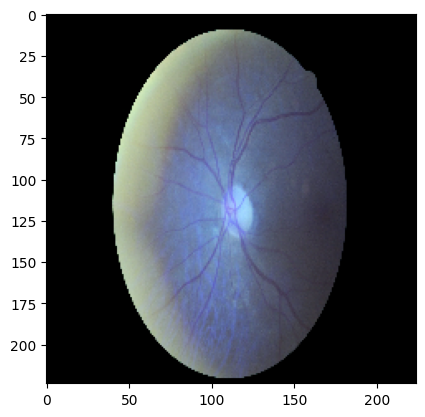

In [ ]:
#load in the train data - explore and clean
training_images=[]
corrupted_data=[]
#count the sample distribution per class 
count={"No DR" :0 , "Mild DR ": 0, "Moderate DR ": 0, "Severe DR ": 0, "Proliferative DR " : 0}
IMG_SIZE = 224
REBUILD = True




def inspect(path):
#iterate through the data in subsets, iterating through x images at a time
#for chunk in np.array_split(df, 1000):
    for idx ,i in tqdm(df.iterrows(), total=len(df)):
        try:
            img_path = os.path.join(path, f"{i['image']}.jpeg")
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))
            label = df.iloc[idx]["level"]

            #ensure there are no corrupted files
            if img is None:
                print(f"error occured processing at row{df.iloc[idx]}")
                #skip the current iteration
                continue
                
            if pd.isna(label):
                #if any image within the csv file does not contain a label, we append the index of the the row, allowing us to later filter out
                corrupted_data.append(df.iloc[idx])

            #count the distribution of samples per class
            if label == 0:
                count["No DR"]+=1

            elif label == 1:
                count["Mild DR"]+=1

            elif label == 2:
                count["Moderate DR"]+=1

            elif label == 3:
                count["Severe DR"]+=1

            elif label == 4:
                count["Proliferative DR"]+=1                   


            #convert the labels to their to their label encoding format
            training_images.append([np.array(img), df.iloc[idx]["level"]])

        except Exception as e:
            print(f"error has occured at {i}")
            
       
    return training_images    


if REBUILD:
    train_data = inspect(path)

img, label = train_data[0][0], train_data[0][1]
print(img.shape)

#the mean value of pixels
print(np.mean(img))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()







    

In [43]:
#check to see if there are any images with missing labels
print(f"The number of msising labels found in the dataset are : {len(corrupted_data)}")
print(len(train_data))

The number of msising labels found in the dataset are : 0
35126


In [30]:
print(img.shape)
print(label)

(224, 224, 3)
0


Min pixel value: 0, Max pixel value: 255
35126


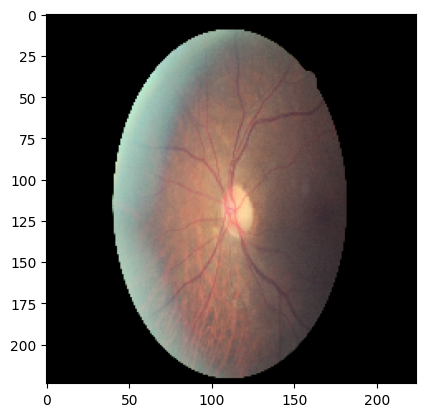

In [32]:
#print max and min pixel values of our image to see if normalized already or not
print(f"Min pixel value: {train_data[0][0].min()}, Max pixel value: {train_data[0][0].max()}")

#printing the length of our dataset
print(len(train_data))
#(3662, 224,224, 3), this represents the number of samples , and the shape of each image with 3 channels RGB

#visualize the first fundus image in the datset, ensure its in RGB
plt.imshow(cv2.cvtColor(train_data[0][0], cv2.COLOR_BGR2RGB))
plt.show()

4
DR label being shown is : 4


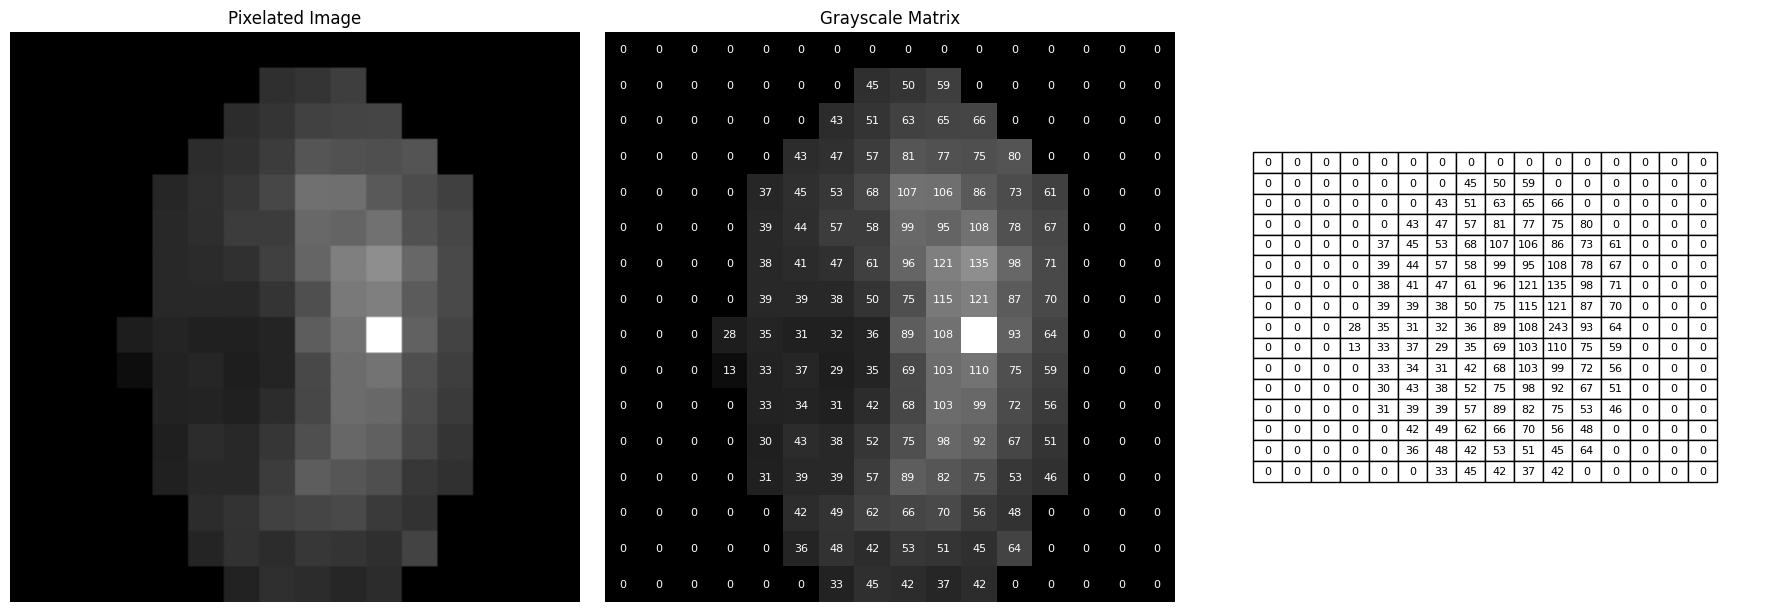

In [ ]:
# Display the pixel intensity values of a patient with Proliferative DR 
PDR_img = train_data[1613][0]  # Access the image of a patient with PDR (Proliferative DR)
print(f"DR label being shown is : {df.iloc[1613]["level"]}")

# Ensure the image is in grayscale
if len(PDR_img.shape) == 3:  # If the image has 3 channels (RGB/BGR)
    PDR_img = cv2.cvtColor(PDR_img, cv2.COLOR_BGR2GRAY)

# Resize the image to make it pixelated (16x16)
pixelated_image = cv2.resize(PDR_img, (16, 16), interpolation=cv2.INTER_NEAREST)

# Resize it back to the original size for visualization purposes
pixelated_resized = cv2.resize(pixelated_image, (PDR_img.shape[1], PDR_img.shape[0]), interpolation=cv2.INTER_NEAREST)

# Prepare the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Display the pixelated image resized back to the original size
axes[0].imshow(pixelated_resized, cmap='gray')
axes[0].set_title("Pixelated Image")
axes[0].axis('off')

# 2. Display the grayscale pixel values as an image
axes[1].imshow(pixelated_image, cmap='gray')
for i in range(pixelated_image.shape[0]):
    for j in range(pixelated_image.shape[1]):
        value = pixelated_image[i, j]
        # Display the pixel value on the image
        axes[1].text(j, i, f"{value}", color='white', ha='center', va='center', fontsize=8)
axes[1].set_title("Grayscale Matrix")
axes[1].axis('off')

# 3. Display the raw pixel values in a table format
axes[2].axis('tight')
axes[2].axis('off')
table_data = pixelated_image.astype(int)  # Ensure integer values for display
pixel_table = axes[2].table(
    cellText=table_data, loc='center', cellLoc='center', colWidths=[0.05] * 16
)
pixel_table.auto_set_font_size(False)
pixel_table.set_fontsize(8)

# Adjust layout for better visualization

plt.tight_layout()
plt.show()



# The pathology of Diabetic Retinopathy 
- Below is an Image of indicators we can notice in a DR patient

In [63]:
diagram_path = os.getenv("DIAGRAM_IMG")

# Display the image
display(Image(filename=diagram_path, width=600)) 


ValueError: No image data found. Expecting filename, url, or data.

# Raw Samples of Images before any Preprocessing
In this section we view the raw images of gradings without any preprocessing - note images were only just resized 

Appended image at index 0 for label 0
Appended image at index 1 for label 0
Appended image at index 4 for label 1
Appended image at index 5 for label 2
Appended image at index 6 for label 4
Appended image at index 7 for label 4
Appended image at index 9 for label 1
Appended image at index 23 for label 2
Appended image at index 90 for label 3
Appended image at index 91 for label 3


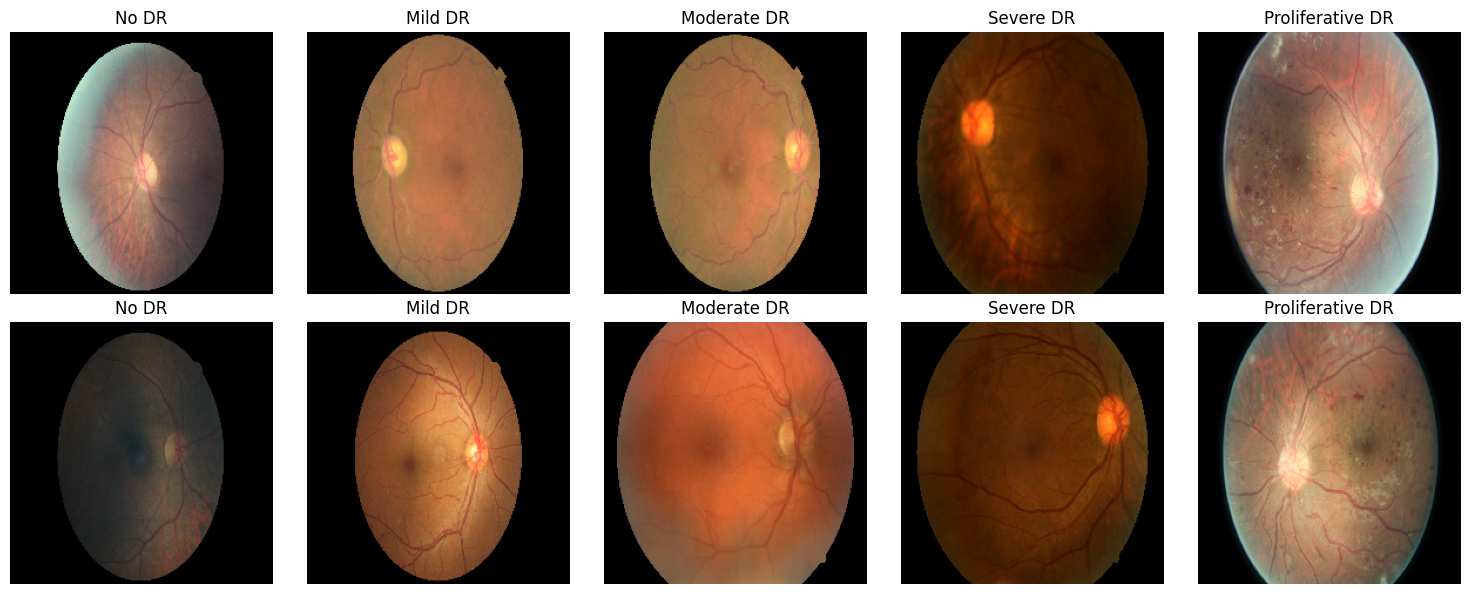

In [ ]:
#show some samples with their labels
#iterate through the samples
#if we get 2 samples of a single grading, then stop searching for that label

def fetch_samples(train_data, num_of_classes=5):
    sample_dict = {label: [] for label in range(num_of_classes)}
    
    for idx , data in enumerate(train_data):
         
        X, y  = data
        label = y
        

        #check if we already have the label in our dict
        if label not in sample_dict:
            sample_dict[label] = []
        
        if len(sample_dict[label])<2:
            sample_dict[label].append(X) 
            #confirmation to ensure we plot the exact images for each coressponding label
            print(f"Appended image at index {idx} for label {label}")
        #now if all samples have a list of 2, then exit the iteration
        # meaning {0:[img1,img5] etc}   

        #returns true if (sample) is true for all values in the iterable
        if all(len(sample)==2 for sample in sample_dict.values()):
            break

    return sample_dict    


data = fetch_samples(train_data)





#visualize 2 samples per grading with titles -  10 in total
def visualize_samples(samples):
    # Create a figure with 5 columns (for 5 labels) and 2 rows (for 2 images per label)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # 2 rows, 5 columns

    # Iterate over the dictionary of samples
    for label, images in samples.items():
        for i, img in enumerate(images):
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # Access the correct subplot using label and row index
            ax = axes[i, label]  # Row `i` and column `label`


            #change the value of lables to their correct severity gradings
            class_name= None

            if label == 0:
                class_name = "No DR"

            elif label == 1: 
                class_name = "Mild DR"    

            elif label == 2:
                class_name = "Moderate DR"  

            elif label == 3:
                class_name = "Severe DR"    

            elif label == 4:
                class_name = "Proliferative DR"      


            # Plot the image
            ax.imshow(img, cmap="gray")  # Use 'gray' or other colormaps as necessary
            ax.set_title(f"{class_name}")  # Set the title to show the class
            ax.axis("off")  # Turn off axes for cleaner visualization

    # Adjust layout
    plt.tight_layout()
    plt.show()


unprocessed_samples = visualize_samples(data)
unprocessed_samples



In [45]:
#number of samples per class
print(count)

{'No DR': 25810, 'Mild DR': 2443, 'Moderate DR': 5292, 'Severe DR': 873, 'Proliferative DR': 708}


# Class Distributions

A cruical part of data exploration is understanding the distributions of samples within the dataset.

- If the prevelence of the Majority class with respect to the Minority classes is high, then this leads to a biased model.

- A biased model will further affect generalizability as the model is not well trained on other DR gradings

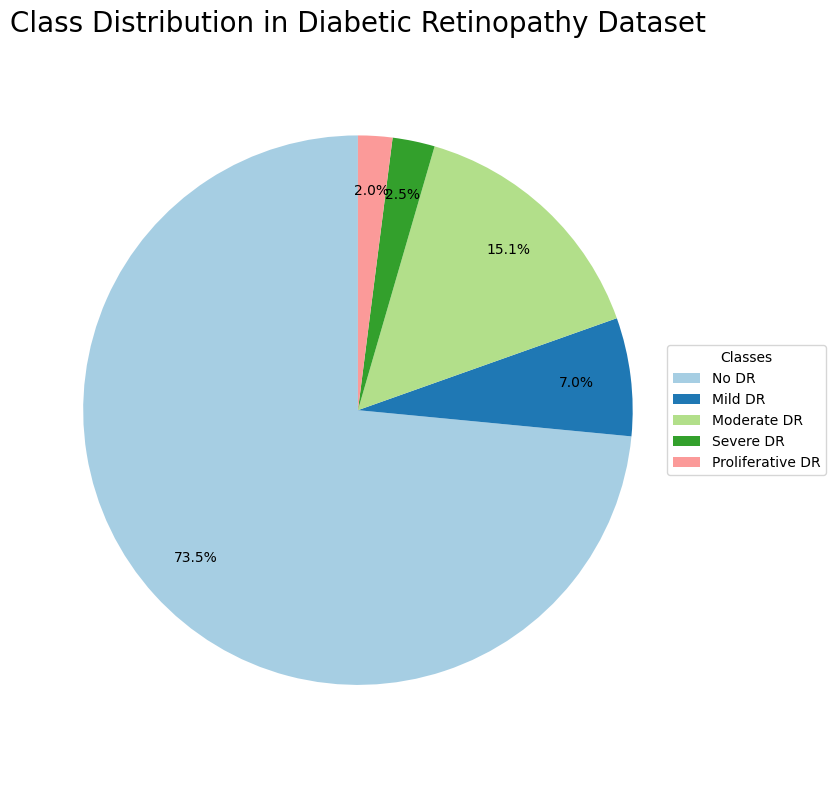

In [65]:
# Pie Chart

labels = count.keys()
sizes = count.values()

plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    sizes, 
    autopct='%1.1f%%', 
    startangle=90,
    colors=plt.cm.Paired.colors, 
    pctdistance=0.8  # Adjust distance of the % labels from center
)

# Create a legend on the right side
plt.legend(wedges, labels, title="Classes", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title("Class Distribution in Diabetic Retinopathy Dataset", fontsize=20)
plt.axis('equal')  # Ensures pie is drawn as a circle
plt.tight_layout()
plt.show()


<BarContainer object of 5 artists>

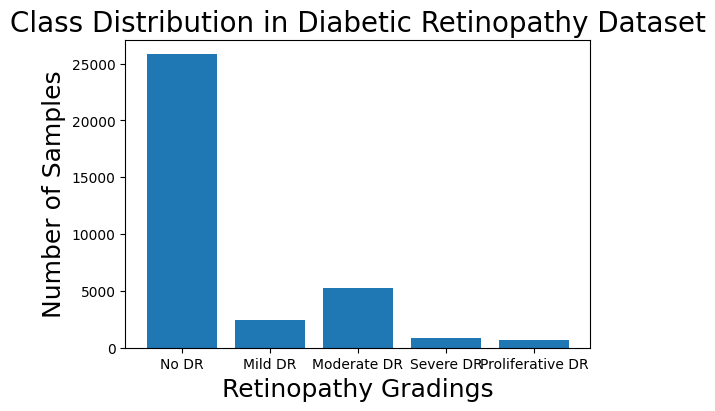

In [54]:
#visualising the class imbalance with a bar chart
plt.figure(figsize=(6, 4))  
plt.xlabel("Retinopathy Gradings", fontsize=18)
plt.ylabel("Number of Samples", fontsize=18)
plt.title("Class Distribution in Diabetic Retinopathy Dataset", fontsize=20)


plt.bar(count.keys(), count.values())
#plt.show()

In [ ]:
from PIL import Image
def find_black_images(file_path, df):
    """
    Creates a column of images that are not black (np.mean(img) != 0)

    INPUT
        file_path: file_path to the images to be analyzed.
        df: Pandas DataFrame that includes all labeled image names.

    OUTPUT
        Column indicating if the photo is pitch black or not.
    """
    black_list = []
    for img in tqdm(df["image"]):
        # Construct the image path
        img_path = os.path.join(file_path, f"{img}.jpeg")
        try:
            # Open the image 
            img = Image.open(img_path)
            # Calculate the mean pixel value
            img_mean = np.mean(np.array(img))

            if(img_mean == 0):
                print(img_path)
            # Append 1 if the image is black (mean == 0), else 0
            black_list.append(1 if img_mean == 0 else 0)
        except Exception as e:
            print(f"Error processing image {img_path}: {e}")
            black_list.append(0)  # Assume not black if there's an error
    return black_list

# Load the labels
trainLabels = pd.read_csv(os.getenv("DR_LABELS_PATH"))

# Initialize the 'black' column
trainLabels['black'] = np.nan

# Populate the 'black' column
trainLabels['black'] = find_black_images(os.getenv("DR_IMAGES_PATH"), trainLabels)

# Filter out black images
trainLabels = trainLabels.loc[trainLabels['black'] == 0]

# Save the filtered data
trainLabels.to_csv('trainLabels_master.csv', index=False, header=True)

print("Completed")




# Images with Mean of 0 were dropped
403 Images were dropped Due to them having a black colour space 

In [ ]:
df_prev = pd.read_csv(os.getenv("DR_LABELS_PATH"))
df_new = pd.read_csv("/Users/abas/Projects/DR/Diabetic-Retinopathy-Detection/Notebooks/trainLabels_master.csv")

def compare_csv(prev, new):
    return len(prev) == len(new)


print(compare_csv(df_prev, df_new))
print(len(df_prev))
print(len(df_new))



False
35126
34723
403


# Splitting Train/Val/Test
- As we can see from the above Severity gradings, No DR has 25,810 samples which is exactly 73.5% of the total distribution.
- we will begin with splitting the data into  a 70/15/15 split
- having a good amount of data for val and tests are crucial to understand how the model is performing
- with the usage of the val set we can fine tune hyperparameters whilst training and adjust any model architectures if we may



Initially we split the dataset into their 3 subsets of train, test and val. we then apply augmentations to the trainset alone to improve generalization and to reduce overfitting - overfitment occurs when the model has memorised patterns from the training data and performs poorly on unseen data. Hence if we augment our data the model is less likely to overfit to the majority class (No dr) & we improve generalization by feeding the model with extra information as it sees a variety of samples from the minority class. 



In [149]:
# from sklearn.model_selection import train_test_split
# from sklearn.utils import shuffle

# """
# we begin by splitting our dataset into a 70/15/15 split with stratified sampling, this ensure that our subsets all maintain the original distributions
# from the original dataset. 
# the Random seed ensures we always run the same splits

# Assume x (inputs) and y (labels) are defined.
# First, we split off the test set:
# Then split the remaining data into training and validation sets:
#  This results in roughly 80% training, 10% validation, and 10% test.
# """

# RANDOM_SEED = 77
# TEST_SIZE=0.5 # for the val/test split

# #use the csv that filterd out black images
# df = pd.read_csv("/Users/abas/Projects/DR/Diabetic-Retinopathy-Detection/trainLabels_master.csv")
# df.drop(columns="black")
# image, label = df["image"], df["level"]
# #shuffle our training data
# X, y = shuffle(image, label, random_state=RANDOM_SEED)

# #first lets split it 70/30 and use the 30% to split it into the val and test
# train_x, x_temp, train_y , y_temp = train_test_split(X, y , test_size=0.3 ,random_state=RANDOM_SEED, stratify=y)
# #now that we've splitted the train and test, we can split the val set from the X_train and y_train
# val_x, test_x , val_y ,test_y = train_test_split(x_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp)

# print(f"train set consists of {train_x.shape} samples")
# print(train_y.shape)


# print(f"val set consists of {val_x.shape} samples")
# print(val_y.shape)

# print(f"test set consists of {test_x.shape} samples")
# print(test_y.shape)



# #due to the val/test size being an odd number the .5 split isnt exactly even. Mismatch of one sample between them




# Using a subset of 10% of the original data for initial development and training pipeline


len of new subset is  :3472
Development set class distribution:
{0: 2549, 1: 244, 2: 522, 3: 86, 4: 71}


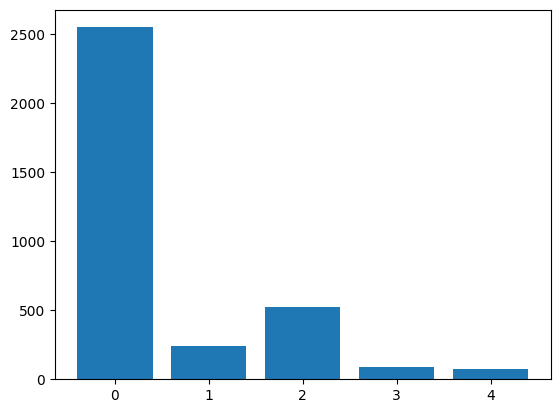

In [167]:
from sklearn.model_selection import train_test_split

def split_data_by_pct(pct, df_fullDataset, seed):
    #10% of the data remains in the development dataframe and the 90% rest is discarded
    dev_df, _= train_test_split(df_fullDataset, test_size=pct, random_state=seed, stratify=df_fullDataset["level"])
    return dev_df



dev_df = split_data_by_pct(0.9, df, 77)
print(f"len of new subset is  :{len(dev_df)}")
#counts the number of samples for each unique level
dev_count = dev_df.groupby('level').size()
print("Development set class distribution:")
dev_dict = {grade:samples for grade,samples  in dev_count.items()}
print(dev_dict)


plt.bar((dev_dict.keys()), (dev_dict.values()))
#plt.show()

#drop the black column that was previously there
dev_df = dev_df.drop(columns="black")
with open("dr_dev.csv", "wb") as f:
    dev_df.to_csv(f, index = False)



# Exploratory analysis on the Image Properties, this will later be used when we scale up to the full dataset.

From this we can see which images are majority black and the mean of the channels
some of the image properties include
- black pixel count
- pct of black pixels 
- height and width of the images (will need to be scaled down to a consistent size later)

In [ ]:

black_images = []
def image_properties(dataset, file_path): 
    """
    This takes an input of either the train set or validation set
    And a file path to the Image directory
    we can understand which images would need to be dropped based on the summary
    OUTPUT - a 
    """
    train_results = []
   
    for index, row in tqdm(dataset.iterrows(), total = len(dataset)):
        img_path = os.path.join(file_path,f"{row["image"]}")
        #for each image get the shape
        img = cv2.imread(img_path)
        height, width, _ = img.shape
        ratio = width/height #ratio of the width to the height
        pixel_count = height*width

        #convert the image into grayscale, which makes it easier to find the number of black pixels as we use nonzero function
        gray_scaled = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        black_pixels = pixel_count - cv2.countNonZero(gray_scaled)
        black_pct = black_pixels/pixel_count * 100 #percentage of how dark each image is, if a threshold less than a certain pct we may remove

        if(black_pct > 90):
            print(img_path)
            #append the path of the image to this list
            black_images.append(img_path)
        red_mean, green_mean, blue_mean, _ = cv2.mean(img)
    

        #convert all to a dataframe to view summmary
        observation = np.array(
        (img_path, height, width, ratio, pixel_count, black_pixels, black_pct, red_mean, green_mean, blue_mean))

        train_results.append(observation)

        train_results_df = pd.DataFrame(train_results)
        train_results_df.columns = [
        'image','height','width','ratio','pixel_count','black_cnt','black_pct','r_mean','g_mean','b_mean']

    return train_results_df


inspect_properties = image_properties(dev_df, path)
print(black_images)


inspect_properties.head()
inspect_properties.tail()

#inspect random samples
inspect_properties.sample(20)










100%|██████████| 3472/3472 [01:32<00:00, 37.48it/s]


[]


,image,height,width,ratio,pixel_count,black_cnt,black_pct,r_mean,g_mean,b_mean
2033,/Users/abas/Projects/DR/Diabetic-Retinopathy-D...,2592,3888,1.5,10077696,2077588,20.615704224457655,71.22405924925697,88.3855083542905,101.56349655714956
3325,/Users/abas/Projects/DR/Diabetic-Retinopathy-D...,3168,4752,1.5,15054336,6823049,45.32281596478251,51.10182979840492,63.8513989590773,75.87481427277828
246,/Users/abas/Projects/DR/Diabetic-Retinopathy-D...,2592,3888,1.5,10077696,1373840,13.632481075039374,35.16894198832749,57.72433629670908,85.4811433089468
2663,/Users/abas/Projects/DR/Diabetic-Retinopathy-D...,2592,3888,1.5,10077696,2155229,21.38612833727074,69.44115063601839,89.44995909779378,103.23538921991693
2557,/Users/abas/Projects/DR/Diabetic-Retinopathy-D...,1920,2560,1.3333333333333333,4915200,1054668,21.457275390625,14.685443115234376,21.646826171875002,26.550205078125003
2292,/Users/abas/Projects/DR/Diabetic-Retinopathy-D...,1944,2592,1.3333333333333333,5038848,1653073,32.80656610399838,51.83743526298074,77.15831376536859,119.57944534147487
2404,/Users/abas/Projects/DR/Diabetic-Retinopathy-D...,2592,3888,1.5,10077696,1981945,19.666648011609002,113.26679848251028,126.86821749733272,142.6627947499111
2148,/Users/abas/Projects/DR/Diabetic-Retinopathy-D...,1944,2592,1.3333333333333333,5038848,1808414,35.88943345780623,35.97559104779505,57.22853418082863,86.89547432270233
998,/Users/abas/Projects/DR/Diabetic-Retinopathy-D...,3168,4752,1.5,15054336,8049472,53.46945889875183,17.371744791666664,28.97047847211594,69.26554734795343
103,/Users/abas/Projects/DR/Diabetic-Retinopathy-D...,2304,3456,1.5,7962624,4499818,56.51174788612398,32.39900615676441,43.03149577325264,44.27190509058321


# We must consider that due to the noise of the image, some of the images may have a high a black pixel pct count
# Images below are before removing any noise
- hence we need to crop the image, and make sure features are visbile at the point of interest

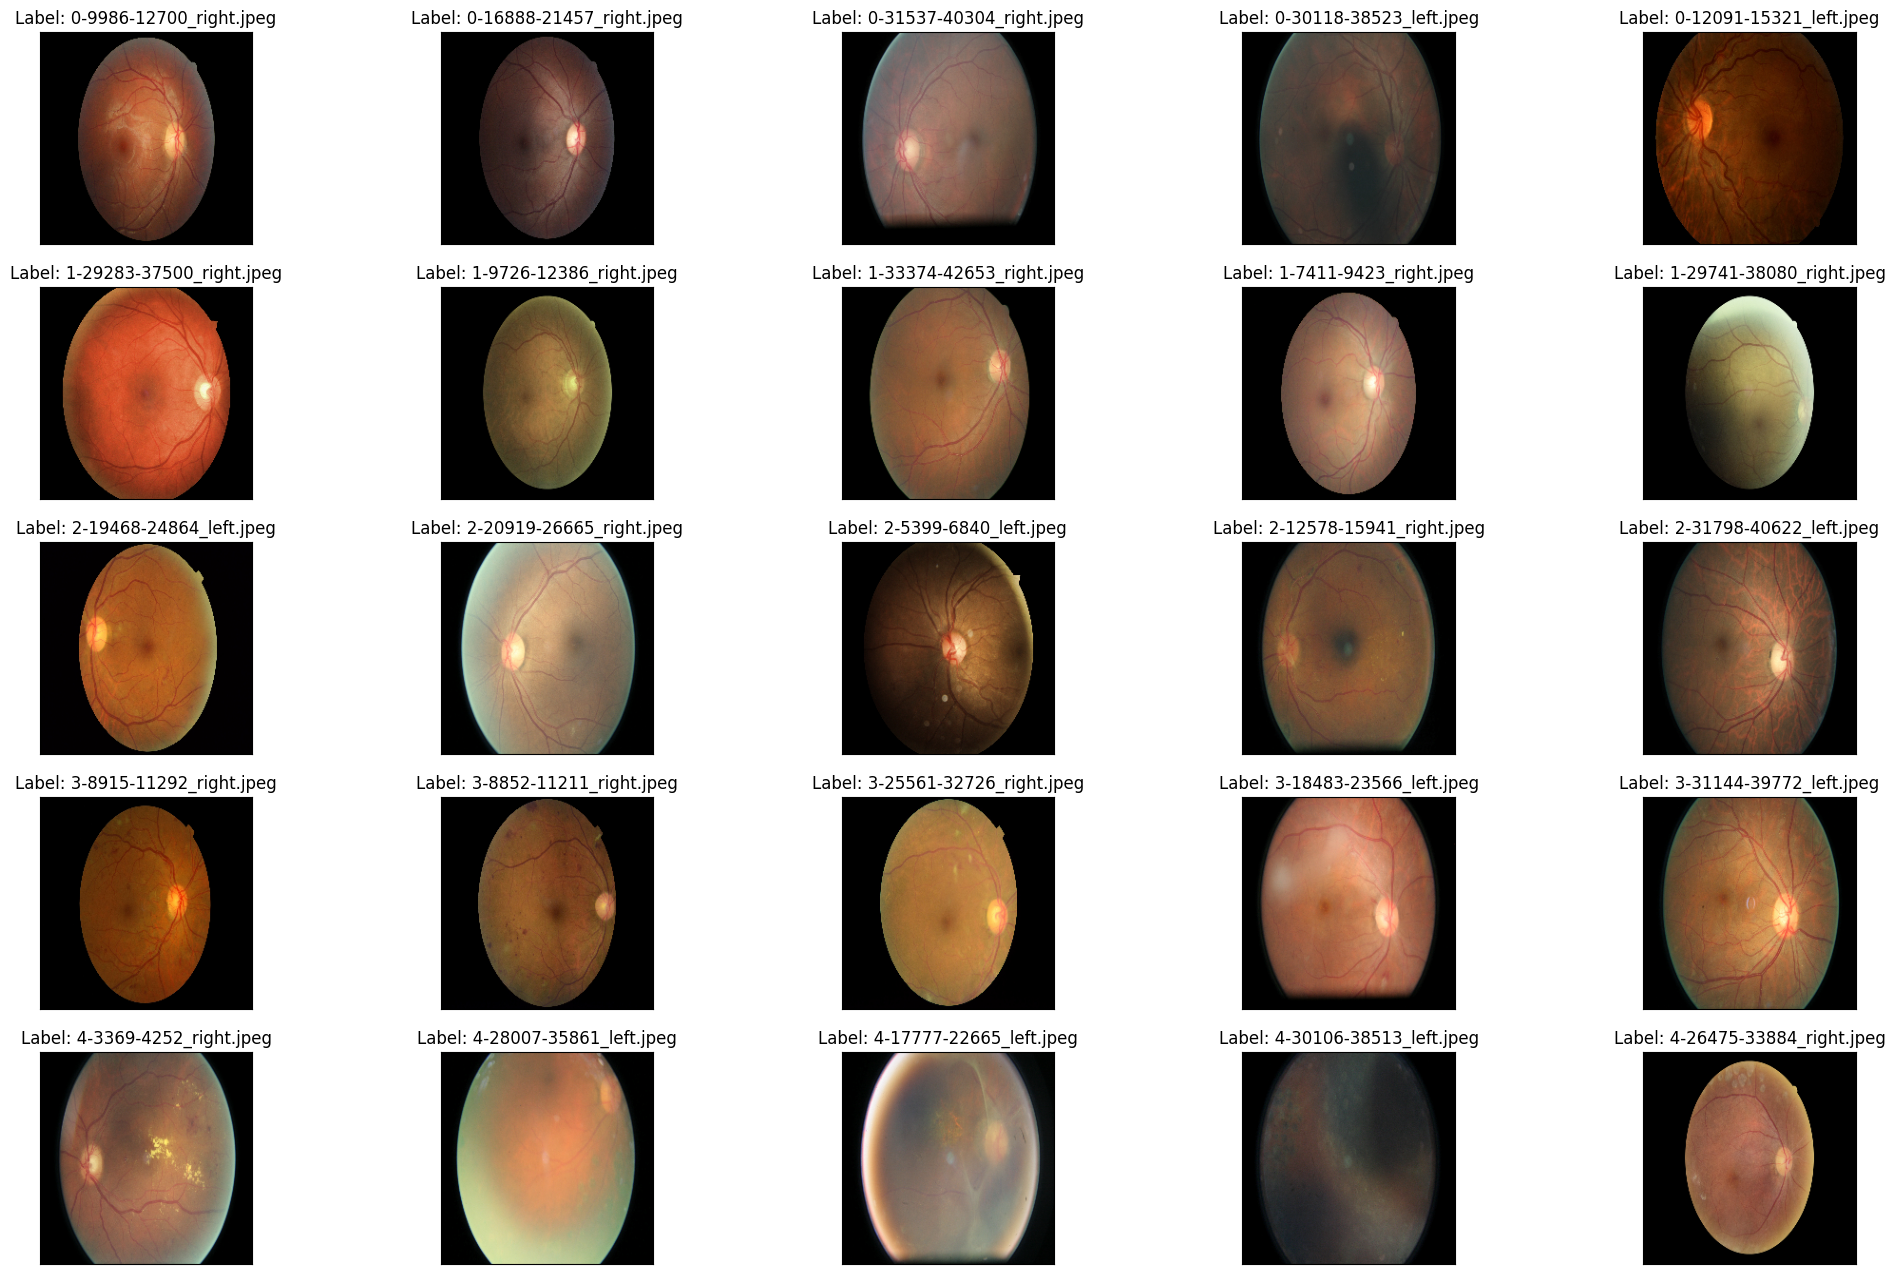

In [183]:
fig = plt.figure(figsize=(25, 16))
# display 10 images from each class to show the noise of the image
for class_id in sorted(dev_df["level"].unique()):
    for i, (idx, row) in enumerate(dev_df.loc[dev_df['level'] == class_id].sample(5, random_state=77).iterrows()):
        ax = fig.add_subplot(5, 5, class_id * 5 + i + 1, xticks=[], yticks=[])
        image = cv2.imread(os.path.join(path,f"{row["image"]}"))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        plt.imshow(image)
        ax.set_title('Label: %d-%d-%s' % (class_id, idx, row['image']) )

(2592, 3888, 3)
im here
(2592, 3320) (2592, 3320) (2592, 3320)
(2592, 3320, 3)
(2336, 3504, 3)


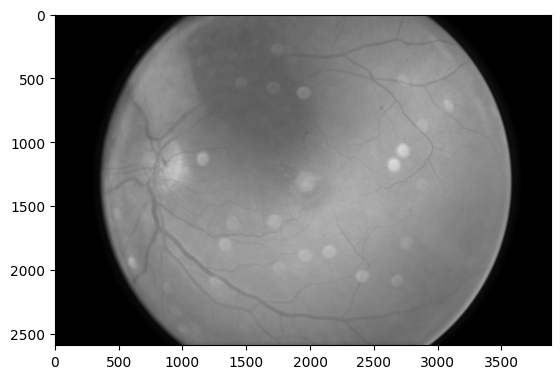

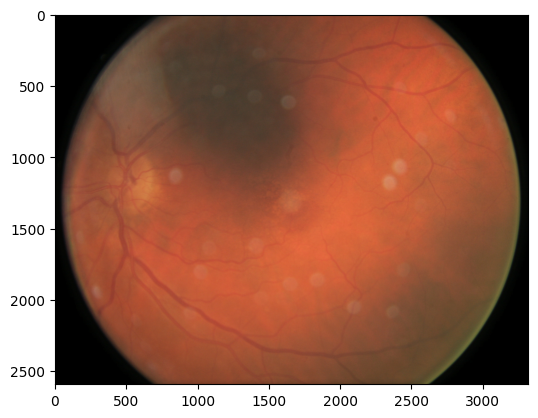

In [216]:
def crop_image(image, tolerance):
    flag_images = []
    img = cv2.imread(image)
    #img = cv2.resize(img, (224,224))
    """
    we return a boolean mask that returns 1,0 (T/F) for every pixel value that is greater or less than the tolerance
    the mask.any(1) returns a 1d boolean array that sets the row to true, if that row consists of a single pixel value that is greater than tol
    this way we dont delete any informative features. Only fully black rows and columns are deleted

    for rgb we need to crop each channel indivdually and stack them together
    """
    print(img.shape)
    if img.ndim == 2:
        mask = img > tolerance
        #return the index values and return the cropped image
        return img[np.ix_(mask.any(1), mask.any(0))]
    
    elif img.ndim == 3:
        print("im here")
        gray_img = cv2.cvtColor(cv2.imread(image), cv2.COLOR_RGB2GRAY)
        # now for the coloured image we can return that boolean mask, returning to us a 2d spatial dimenstion of 1&0
        mask = gray_img > tolerance
        #we check if the image is fully black, if all rows are 0, meaning we didnt select any row from the mask, then return the image
        check_shape = img[:,:,0][np.ix_(mask.any(1), mask.any(0))].shape[0]
        if(check_shape==0):
            flag_images.append(image)
        #otherwise if the image is not completely black, then for each RGB channel determine which rows and cols to keep that contain at least  a single pixel above the threshold
        else:
            #we return all rows and columns from each channel and stack them together
            img_c1 = img[:,:,0][np.ix_(mask.any(1), mask.any(0))]
            img_c2 = img[:,:,1][np.ix_(mask.any(1), mask.any(0))]
            img_c3 = img[:,:,2][np.ix_(mask.any(1), mask.any(0))]

            #combine the channels
            print(img_c1.shape,img_c2.shape,img_c3.shape)
            img = np.stack([img_c1,img_c2,img_c3],axis=-1)
            print(img.shape)

        return img



        

cropped_img = crop_image(os.path.join(path,dev_df.iloc[2]["image"]), tolerance=7)

before_crop = os.path.join(path,dev_df.iloc[2]["image"])

#the image is actually an rgb
is_sample_coloured = os.path.join(path,dev_df.iloc[0]["image"])
print(cv2.imread(is_sample_coloured).shape)



before_crop = cv2.cvtColor(cv2.imread(before_crop), cv2.COLOR_RGB2GRAY)
cv2.resize(before_crop, (224,224))
plt.imshow(before_crop, cmap="gray")
plt.show()

cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)
plt.imshow(cropped_img_rgb)
plt.show()



